In [78]:
import numpy as np
import matplotlib.pyplot as plt
import xtrack as xt
import bpmeth
import sympy as sp

Define multipole coefficients in a curved frame, then build $\vec{A}$, H and track.


curvature h[m^-1]:  1 radius of curvature [m]:  1.0
E [GeV]:  1.03827208816
beta0:  0.42819548497881543
nphi= 5


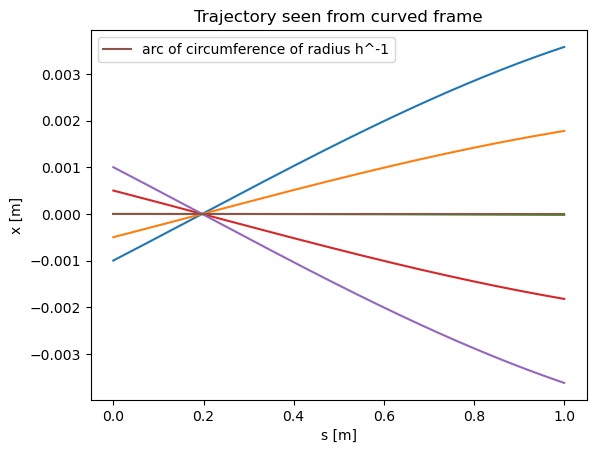

In [79]:
a_curved = [0,]
b_curved = [1, 0.2]
h= b_curved[0]# considering normalization B/Brho=1/rho=h            =1. if checking for a drift
print("curvature h[m^-1]: ", h, "radius of curvature [m]: ", 1/h)
#I want to track protons of given kinetic energy
Ek=1e8 #eV
p=np.sqrt(Ek**2+2*Ek*xt.PROTON_MASS_EV)#momentum eV/c
Eref = Ek + xt.PROTON_MASS_EV
print("E [GeV]: ", Eref/1e9)
gamma0 = Eref/xt.PROTON_MASS_EV
beta0 = np.sqrt(1-1/gamma0**2)
print("beta0: ", beta0)
p0 =xt.Particles(x=np.linspace(-1e-3, 1e-3, 5), y=0, s=0,py=0.01, px=np.linspace(0.005,-0.005,5), ptau=0, beta0=beta0, energy0=Eref, mass0=xt.PROTON_MASS_EV)
p_1 = p0.copy()
nphi=5
print("nphi=",nphi)
A_curved= bpmeth.GeneralVectorPotential(h=h, b=b_curved, a=a_curved, nphi=nphi)
H_curved = bpmeth.Hamiltonian(length=1, h=h, vectp=A_curved)

sol_curved = H_curved.track(p_1, return_sol=True, ivp_opt= {"rtol":1e-10, "atol":1e-12})

for ss in sol_curved:
    plt.plot(ss.t, ss.y[0])
plt.xlabel('s [m]')
plt.ylabel('x [m]')
plt.title("Trajectory seen from curved frame")
x=np.linspace(0,1,50)
y= np.zeros_like(x)
plt.plot(x,y, label='arc of circumference of radius h^-1')
plt.legend()
plt.show()

Then work at the level of the scalar potential because being a scalar it is invariant under change of frame (only the coordinates change). Because of this we can move to the straight frame and perform a harmonic analysis, checking how the a,b coefficients look in that frame.

In [80]:
expansion_curved = bpmeth.FieldExpansion(a=a_curved, b=b_curved, h=h, nphi=7)#, nphi=nphi)
phi_curved = expansion_curved.get_phi()
print("phi curved frame: ", phi_curved)
#transform the scalar potential to curved frame using coordinate transformations
#xcurved =sqrt((x+rho)**2+s**2)-rho       scurved=rho*arctan(s/(x+rho))   with rho=1/h
x, y, s = sp.symbols('x y s', real=True)
xtmp, stmp = sp.symbols("xtmp stmp", real=True)
# rename the curved coordinates temporarily
phi_tmp = phi_curved.xreplace({
    x: xtmp,
    s: stmp
})
# substitute curved -> straight
phi_straight = phi_tmp.xreplace({
    xtmp: sp.sqrt((x + 1/h)**2 + s**2) - 1/h,
    stmp: 1/h * sp.atan(s/(x + 1/h))
})
print("\nphi straight frame: ", phi_straight)

Bxstraight_ana = -phi_straight.diff(x)
Bystraight_ana = -phi_straight.diff(y)
Bsstraight_ana = -phi_straight.diff(s)
print("\nBx straight frame: ", Bxstraight_ana)

phi curved frame:  -y**5*(0.2*x + 0.2)/(120*(1.0*x**4 + 4.0*x**3 + 6.0*x**2 + 4.0*x + 1.0)) + y**3*(0.2*x + 0.2)/(6*(1.0*x + 1)**2) - y*(0.2*x + 1)

phi straight frame:  -0.00166666666666667*y**5*sqrt(s**2 + (x + 1.0)**2)/(4.0*sqrt(s**2 + (x + 1.0)**2) + 1.0*(sqrt(s**2 + (x + 1.0)**2) - 1.0)**4 + 4.0*(sqrt(s**2 + (x + 1.0)**2) - 1.0)**3 + 6.0*(sqrt(s**2 + (x + 1.0)**2) - 1.0)**2 - 3.0) + 0.0333333333333333*y**3/sqrt(s**2 + (x + 1.0)**2) - y*(0.2*sqrt(s**2 + (x + 1.0)**2) + 0.8)

Bx straight frame:  0.00166666666666667*y**5*sqrt(s**2 + (x + 1.0)**2)*(-4.0*(x + 1.0)*(sqrt(s**2 + (x + 1.0)**2) - 1.0)**3/sqrt(s**2 + (x + 1.0)**2) - 12.0*(x + 1.0)*(sqrt(s**2 + (x + 1.0)**2) - 1.0)**2/sqrt(s**2 + (x + 1.0)**2) - 12.0*(x + 1.0)*(sqrt(s**2 + (x + 1.0)**2) - 1.0)/sqrt(s**2 + (x + 1.0)**2) - 4.0*(x + 1.0)/sqrt(s**2 + (x + 1.0)**2))/(4.0*sqrt(s**2 + (x + 1.0)**2) + 1.0*(sqrt(s**2 + (x + 1.0)**2) - 1.0)**4 + 4.0*(sqrt(s**2 + (x + 1.0)**2) - 1.0)**3 + 6.0*(sqrt(s**2 + (x + 1.0)**2) - 1.0)**2 - 3.0)

Remembering that $ \phi_0(x, s) = -a_0(s) - \sum_{n=1}^\infty a_n(s) \frac{x^n}{n!} \\
    \phi_1(x, s) = -\sum_{n=1}^\infty b_n(s) \frac{x^{n-1}}{(n-1)!}  $

Take the coefficient of y in phi_straight, which is $\phi_1$, expand it in a Taylor series in x around 0 up to some order, e.g. 4, (strip the big-O), and store the resulting polynomial’s coefficients in a dictionary keyed by powers of x. This corresponds to

 $\frac{b_n}{(n-1)!}$

 and the same for $a_n$ considering that \\
phi0 = phi_straight.as_coefficients_dict(y)[1]   # phi_0(x, s)$
.

phi1= -(0.2*sqrt(s**2 + (x + 1.0)**2) + 0.8)


<>:44: SyntaxWarning: invalid escape sequence '\p'
<>:89: SyntaxWarning: invalid escape sequence '\p'
<>:44: SyntaxWarning: invalid escape sequence '\p'
<>:89: SyntaxWarning: invalid escape sequence '\p'
/var/folders/5b/bxg2tc4j1gv2774pmy41236m0000gn/T/ipykernel_2109/144430839.py:44: SyntaxWarning: invalid escape sequence '\p'
  plt.title("b(s) in straight frame from transformation of $\phi$")
/var/folders/5b/bxg2tc4j1gv2774pmy41236m0000gn/T/ipykernel_2109/144430839.py:89: SyntaxWarning: invalid escape sequence '\p'
  plt.title("a(s) in straight frame from transformation of $\phi$")


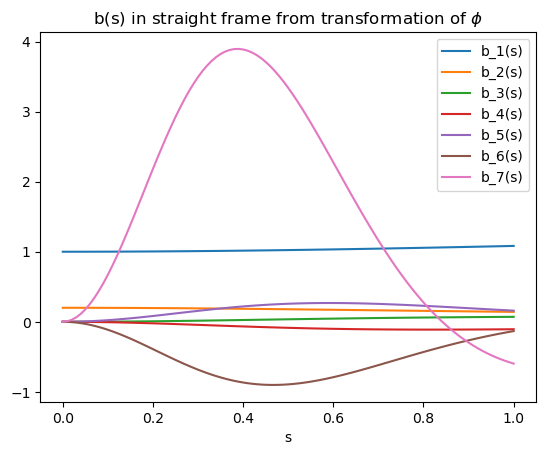

phi0= 0


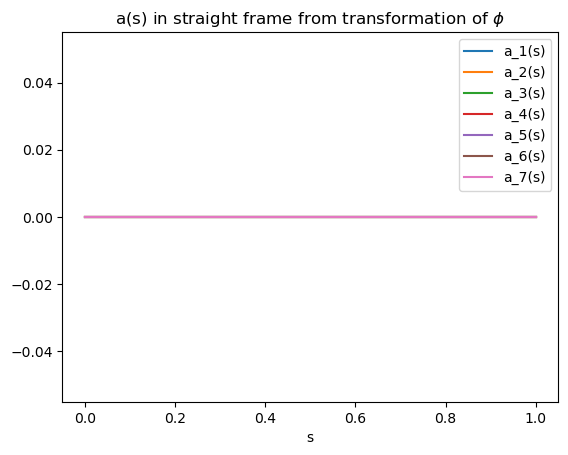

In [81]:
maxordx=6
ns=101
phi1=phi_straight.as_coefficients_dict(y)[y]
print("phi1=",phi1) 
ss = np.linspace(0, 1, ns)
if phi1==0:
    # safety check for when all b_n(s) are zero, one can just create zero arrays with the right shape
  
    b_vals = np.zeros((maxordx+1, ss.size))
else:
    phi1_series = phi1.series(x, 0, maxordx+1).removeO()
    dct_b = phi1_series.as_coefficients_dict(x)
    # ... then extract a_n(s) as in the previous case
    items_b = sorted(dct_b.items(), key=lambda kv: sp.degree(kv[0], x))

b_vals = np.zeros((maxordx+1, ss.size))   # include b_0
if phi1 != 0:
    # 2. Nontrivial phi0: do series in x and extract b_n(s)
    phi1_series = phi1.series(x, 0, maxordx+1).removeO()
    dct_b = phi1_series.as_coefficients_dict(x)

    items_b = sorted(dct_b.items(), key=lambda kv: sp.degree(kv[0], x))

    for k, (xx, vv) in enumerate(items_b):
        if k == 0:
            b_k = -vv                    # b_1(s)
            label = "b_1(s)"
        else:
            b_k = -vv * sp.factorial(k)  # b_k(s)
            label = f"b_{k+1}(s)"

        b_fun = sp.lambdify(s, b_k, 'numpy')
        b_vals[k, :] = b_fun(ss)

        plt.plot(ss, b_vals[k, :], label=label)
else:
    # 3. phi1 == 0: everything is zero; optionally still plot flat lines
    for k in range(maxordx+1):
        label = f"b_{k+1}(s)"
        # a_vals is already zero
        plt.plot(ss, b_vals[k, :], label=label)

plt.legend()
plt.title("b(s) in straight frame from transformation of $\phi$")
plt.xlabel("s")
plt.show()
############################################
phi0 = phi_straight.as_coefficients_dict(y)[1]   # phi_0(x, s)
print("phi0=",phi0)        # you'll see 0 in this case

if phi0 == 0:
    # safety check for when all a_n(s) are zero, one can just create zero arrays with the right shape
    #ss = np.linspace(0, 1, ns)
    a_vals = np.zeros((maxordx+1, ss.size))
else:
    phi0_series = phi0.series(x, 0, maxordx+1).removeO()
    dct_a = phi0_series.as_coefficients_dict(x)
    # ... then extract a_n(s) as in the previous case
    items_a = sorted(dct_a.items(), key=lambda kv: sp.degree(kv[0], x))

a_vals = np.zeros((maxordx+1, ss.size))   # include a_0
if phi0 != 0:
    # 2. Nontrivial phi0: do series in x and extract a_n(s)
    phi0_series = phi0.series(x, 0, maxordx+1).removeO()
    dct_a = phi0_series.as_coefficients_dict(x)

    items_a = sorted(dct_a.items(), key=lambda kv: sp.degree(kv[0], x))

    for k, (xx, vv) in enumerate(items_a):
        if k == 0:
            a_k = -vv                    # a_0(s)
            label = "a_1(s)"
        else:
            a_k = -vv * sp.factorial(k)  # a_k(s)
            label = f"a_{k+1}(s)"

        a_fun = sp.lambdify(s, a_k, 'numpy')
        a_vals[k, :] = a_fun(ss)

        plt.plot(ss, a_vals[k, :], label=label)
else:
    # 3. phi0 == 0: everything is zero; optionally still plot flat lines
    for k in range(maxordx+1):
        label = f"a_{k+1}(s)"
        # a_vals is already zero
        plt.plot(ss, a_vals[k, :], label=label)

plt.legend()
plt.title("a(s) in straight frame from transformation of $\phi$")
plt.xlabel("s")
plt.show()

In [55]:
# evaluate fields on cartesian grid 
xstraightarray = np.linspace(-1, 1, 100)
ystraightarray = np.linspace(-1, 1, 100)
sstraightarray = ss  # same s array used before

Xstraight, Ystraight, Sstraight = np.meshgrid(xstraightarray, ystraightarray, sstraightarray, indexing='ij')
Bxstraight_ana_array = np.asarray(sp.lambdify((x, y, s), Bxstraight_ana, 'numpy')(Xstraight, Ystraight, Sstraight))
Bystraight_ana_array = np.asarray(sp.lambdify((x, y, s), Bystraight_ana, 'numpy')(Xstraight, Ystraight, Sstraight))
Bsstraight_ana_array = np.asarray(sp.lambdify((x, y, s), Bsstraight_ana, 'numpy')(Xstraight, Ystraight, Sstraight))
shape = Xstraight.shape  # reshape to (Nx, Ny, Ns)
Bxstraight_ana_array = np.broadcast_to(Bxstraight_ana_array, shape).copy()
Bystraight_ana_array = np.broadcast_to(Bystraight_ana_array, shape).copy()
Bsstraight_ana_array = np.broadcast_to(Bsstraight_ana_array, shape).copy()
#make a fieldmap object from the field arrays
print(Bxstraight_ana_array.shape)
datastraightfm = np.column_stack((Xstraight.flatten(), Ystraight.flatten(), Sstraight.flatten(), Bxstraight_ana_array.flatten(), Bystraight_ana_array.flatten(), Bsstraight_ana_array.flatten()))
#fm_straight = bpmeth.fieldmaps.Fieldmap(datastraightfm)
#before making the HA, sample the field on a cylindrical grid
ntheta=128
nr=40
def interp_cartesian_to_cylindrical(cart_fieldmap, x_1d, y_1d, s_1d, rmin=0.001, rmax=0.4, nr=128,ntheta=256, ns=40):
    """
    Convert Cartesian fieldmap to cylindrical 
    Parameters
    ----------
    cart_fieldmap : ndarray, shape (N, 6)
        Fieldmap in Cartesian: [x, y, s, Bx, By, Bs]
    x_1d, y_1d, s_1d : 1D arrays
        Coordinate arrays from Cartesian grid
    rmin, rmax, nr : float, int
        Cylindrical radial range and resolution
    ntheta : int
        Azimuthal resolution
    ns : int
        Longitudinal resolution
    Returns
    -------
    fields: list
        list containing Bx, By, Bs
    rr : ndarray
        Radial coordinate array
    s_cyl : ndarray
        Cylindrical s coordinate array
    """
    # Resample Cartesian data onto cylindrical grid
    rr = np.linspace(rmin, rmax, nr)
    theta_1d = np.linspace(0.0, 2*np.pi, ntheta, endpoint=False)
    s_cyl = s_1d
    
    R, TH, S = np.meshgrid(rr, theta_1d, s_cyl, indexing='ij')
    
    # Convert to Cartesian for interpolation
    X_query = R * np.cos(TH)
    Y_query = R * np.sin(TH)
    
    # Reshape for interpolation
    shape_src = (len(x_1d), len(y_1d), len(s_1d))
    query_pts = np.column_stack([
        X_query.ravel(),
        Y_query.ravel(),
        S.ravel(),
    ])
    # Interpolate field components
    from scipy.interpolate import RegularGridInterpolator
    
    fields = {}
    for i, name in enumerate(['Bx', 'By', 'Bs']):
        F_3d = cart_fieldmap[:, 3 + i].reshape(shape_src)
        interp = RegularGridInterpolator(
            points=(x_1d, y_1d, s_1d), values=F_3d,
            method='linear', bounds_error=False, fill_value=np.nan,
        )
        fields[name] = interp(query_pts).reshape(nr, ntheta, ns)
    
    return rr, theta_1d, fields
rr, theta_1d, cylfieldatadict= interp_cartesian_to_cylindrical(datastraightfm, x_1d=xstraightarray, y_1d=ystraightarray, s_1d=sstraightarray, rmin=0.001, rmax=0.5, nr=nr, ntheta=ntheta, ns=ns)
rarr, tarr, sarr = np.meshgrid(rr, theta_1d, sstraightarray, indexing='ij')
cylfieldmapdatastack= np.column_stack([rarr.ravel(), tarr.ravel(), sarr.ravel(), cylfieldatadict['Bx'].ravel(), cylfieldatadict['By'].ravel(), cylfieldatadict['Bs'].ravel()])

<lambdifygenerated-284>:2: RuntimeWarning: invalid value encountered in divide
  return 0.00166666666666667*y**5*sqrt(s**2 + (x + 1.0)**2)*(-4.0*(x + 1.0)*(sqrt(s**2 + (x + 1.0)**2) - 1.0)**3/sqrt(s**2 + (x + 1.0)**2) - 12.0*(x + 1.0)*(sqrt(s**2 + (x + 1.0)**2) - 1.0)**2/sqrt(s**2 + (x + 1.0)**2) - 12.0*(x + 1.0)*(sqrt(s**2 + (x + 1.0)**2) - 1.0)/sqrt(s**2 + (x + 1.0)**2) - 4.0*(x + 1.0)/sqrt(s**2 + (x + 1.0)**2))/(4.0*sqrt(s**2 + (x + 1.0)**2) + 1.0*(sqrt(s**2 + (x + 1.0)**2) - 1.0)**4 + 4.0*(sqrt(s**2 + (x + 1.0)**2) - 1.0)**3 + 6.0*(sqrt(s**2 + (x + 1.0)**2) - 1.0)**2 - 3.0)**2 + 0.00166666666666667*y**5*(x + 1.0)/(sqrt(s**2 + (x + 1.0)**2)*(4.0*sqrt(s**2 + (x + 1.0)**2) + 1.0*(sqrt(s**2 + (x + 1.0)**2) - 1.0)**4 + 4.0*(sqrt(s**2 + (x + 1.0)**2) - 1.0)**3 + 6.0*(sqrt(s**2 + (x + 1.0)**2) - 1.0)**2 - 3.0)) - 0.0333333333333333*y**3*(-x - 1.0)/(s**2 + (x + 1.0)**2)**(3/2) + 0.2*y*(x + 1.0)/sqrt(s**2 + (x + 1.0)**2)
<lambdifygenerated-285>:2: RuntimeWarning: invalid value encountered i

(100, 100, 101)


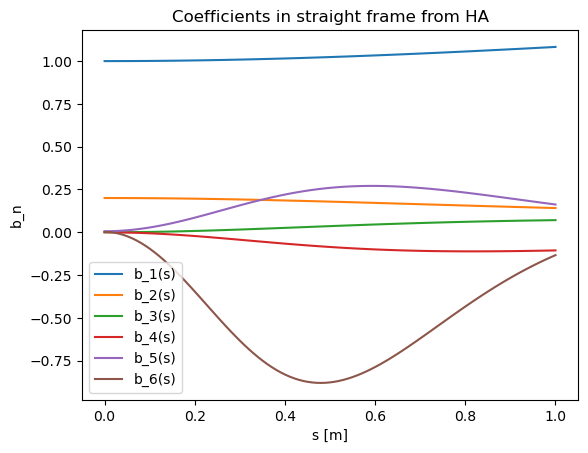

In [ ]:
fm_straight_cyl= bpmeth.fieldmaps.Fieldmap(cylfieldmapdatastack)

svals, astraightofs, bstraightofs, erroras, errorbs = fm_straight_cyl.s_harmonics(rr=rr, ntheta=ntheta, ns=ns, order=maxordx)
for i, b in enumerate(bstraightofs.T):
    plt.plot(svals, b, label=f"b_{i+1}(s)")
plt.xlabel('s [m]')
plt.ylabel('b_n')
plt.title('Coefficients in straight frame from HA')
plt.legend()
plt.show()

As expected an s dependence appeared. To asses the importance of not neglecting it we can see what are the predictions of a naive tracking that would disregard the effect of curvature compared with a more advanced one. 

We can make a quality check on the HA by plotting the difference of its result with the results from the analytical expansion of $\phi$

<>:3: SyntaxWarning: invalid escape sequence '\D'
<>:12: SyntaxWarning: invalid escape sequence '\D'
<>:3: SyntaxWarning: invalid escape sequence '\D'
<>:12: SyntaxWarning: invalid escape sequence '\D'
/var/folders/5b/bxg2tc4j1gv2774pmy41236m0000gn/T/ipykernel_2109/3458625727.py:3: SyntaxWarning: invalid escape sequence '\D'
  plt.plot(svals, d, label=f"$\Delta$b_{i+1}(s)")
/var/folders/5b/bxg2tc4j1gv2774pmy41236m0000gn/T/ipykernel_2109/3458625727.py:12: SyntaxWarning: invalid escape sequence '\D'
  plt.plot(svals[20:], d[20:], label=f"$\Delta$b_{i+1}(s)")


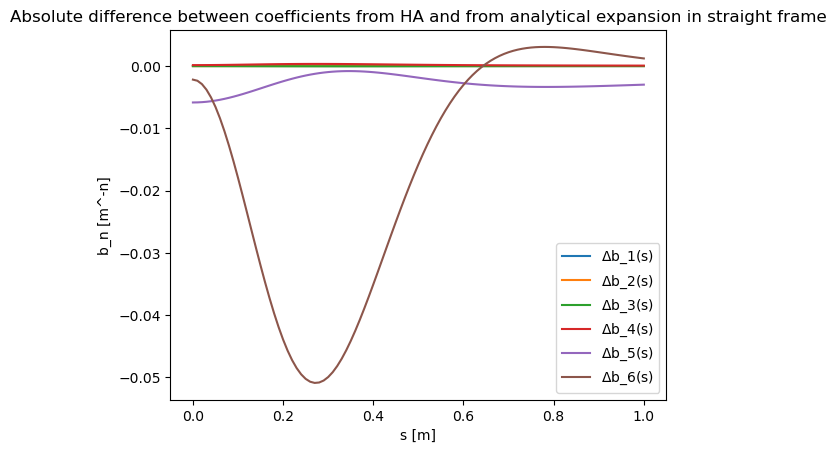

/var/folders/5b/bxg2tc4j1gv2774pmy41236m0000gn/T/ipykernel_2109/3458625727.py:10: RuntimeWarning: divide by zero encountered in divide
  reldeltab=deltab/b_vals[1:]


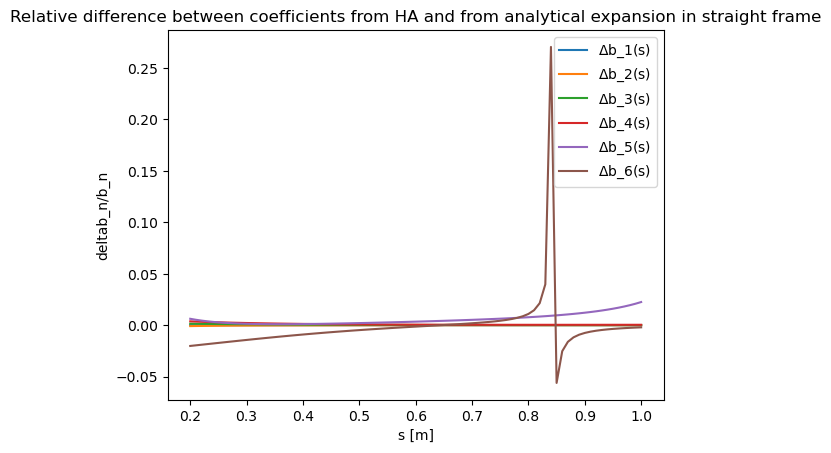

In [57]:
deltab=b_vals[:maxordx]-bstraightofs.T #note that b_vals includes b_0 while bstraightofs starts from b_1
for i, d in enumerate(deltab[:6]):
    plt.plot(svals, d, label=f"$\Delta$b_{i+1}(s)")
plt.xlabel('s [m]')
plt.ylabel('b_n [m^-n]')
plt.title('Absolute difference between coefficients from HA and from analytical expansion in straight frame')
plt.legend()
plt.show()

reldeltab=deltab/b_vals[1:]
for i, d in enumerate(reldeltab[:6]):
    plt.plot(svals[20:], d[20:], label=f"$\Delta$b_{i+1}(s)")
    
plt.xlabel('s [m]')
plt.ylabel('deltab_n/b_n')
plt.title('Relative difference between coefficients from HA and from analytical expansion in straight frame')
plt.legend()
plt.show()

The result from the HA is quite good up to order 6. It would be a good idea to see if this high order imperfections actually account for some deviations in the predicted trajectory.

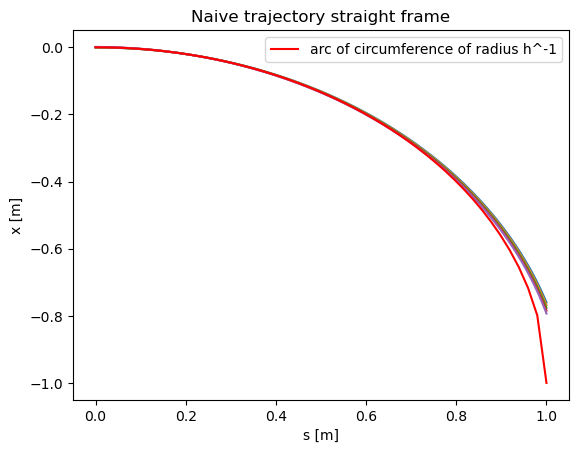

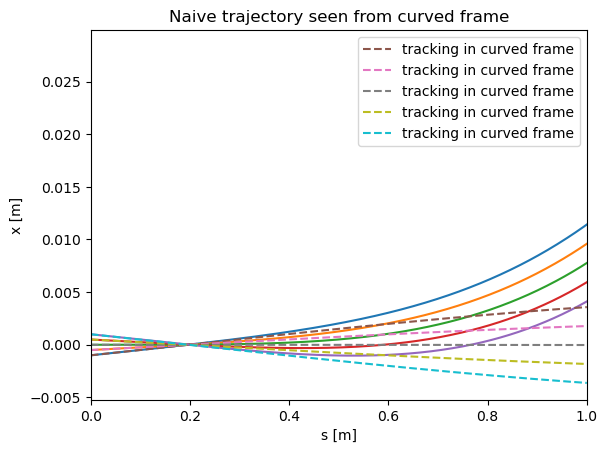

In [58]:
Astrnaive=bpmeth.GeneralVectorPotential(h=0, b=b_curved, a=a_curved, nphi=5)#uses the original simple coefficients disregarding the curvature
Hstrnaive = bpmeth.Hamiltonian(length=1,h=0, vectp=Astrnaive)
p_2 = p0.copy()
sol_strnaive = Hstrnaive.track(p_2, return_sol=True, ivp_opt= {"rtol":1e-10, "atol":1e-12})
for ss in sol_strnaive:
    plt.plot(ss.t, ss.y[0])
plt.xlabel('s [m]')
plt.ylabel('x [m]')
plt.title("Naive trajectory straight frame")
x=np.linspace(0,1,50)
y= -1/h +np.sqrt(h**-2 -x**2)
plt.plot(x,y, color='red', label='arc of circumference of radius h^-1')
plt.legend()
plt.show()

#visualise from the pov of the curved frame
for ss in sol_strnaive:
    xc=np.sqrt((ss.y[0]+1/h)**2+ss.t**2)-1/h
    sc=np.arctan(ss.t/(ss.y[0]+1/h))/h
    plt.plot(sc,xc)
plt.xlabel('s [m]')
plt.ylabel('x [m]')
plt.title("Naive trajectory seen from curved frame")
# x=np.linspace(0,1,50)
# y= np.zeros(50)
# plt.plot(x,y, color='red', label='arc of circumference of radius h^-1')
for ss in sol_curved:
    plt.plot(ss.t, ss.y[0],'--',label='tracking in curved frame')
plt.legend()
plt.xlim((0., 1.))#because H curved has length 1
plt.show()


If we want to be more precise we can stay in the straight frame but account for the s dependence of the coefficients

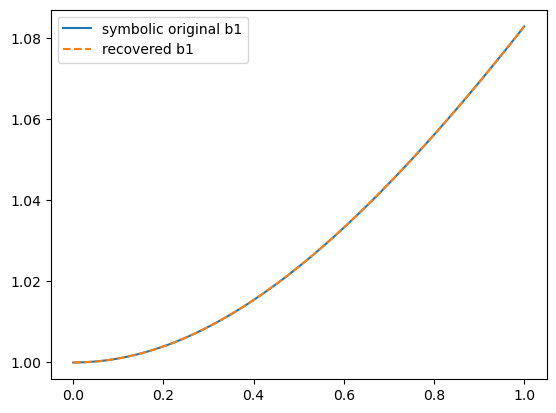

In [59]:
# Use a Chebyshev basis on [0,1] and a moderate degree to reduce ill-conditioning.
degree = 10
b_nfit = []
a_nfit = []

s = sp.symbols('s')

for arr, dst in [(bstraightofs, b_nfit), (astraightofs, a_nfit)]:
    for j in range(arr.shape[1]):
        cheb = np.polynomial.Chebyshev.fit(sstraightarray, arr[:, j], deg=degree, domain=[0, 1])
        poly = cheb.convert(kind=np.polynomial.Polynomial)
        coeffs = poly.coef
        poly_expr = sum(sp.Float(coeffs[i]) * s**i for i in range(len(coeffs)))
        dst.append(str(sp.expand(poly_expr)))


plt.plot(sstraightarray, bstraightofs[:,0], label="symbolic original b1")
b1ofslambdified = sp.lambdify(s, b_nfit[0], modules='numpy')
b1_eval = b1ofslambdified(sstraightarray)
b1_eval = np.broadcast_to(b1_eval, sstraightarray.shape)  # works for scalar or array
plt.plot(sstraightarray, b1_eval,'--', label='recovered b1')
plt.legend()
plt.show()


<lambdifygenerated-307>:3: RuntimeWarning: invalid value encountered in sqrt
  return [-(-px - y**7*(-8.11833637434994e-12*s**9 + 5.58837357221437e-11*s**8 - 1.53177769559994e-10*s**7 + 2.18451315075111e-10*s**6 - 1.75863258099106e-10*s**5 + 7.98910441456962e-11*s**4 - 1.85698785812681e-11*s**3 + 1.32641344108789e-12*s**2 + 2.02713267726138e-13*s - 1/3628800*x**6*(0.00247462479896025*s**3 - 0.00567814520527843*s**2 + 0.00374738875935448*s - 0.000735203834519434) - 1/604800*x**5*(-0.000332113249651365*s**3 + 0.000453847997047503*s**2 - 0.000191900770820165*s + 2.46629819539464e-5) - 1/120960*x**4*(7.97620399448127e-6*s**3 - 9.58538293752133e-6*s**2 + 3.26868968784043e-6*s - 2.70850690038981e-7) - 1/40320*x**4*(0.000123731239948012*s**5 - 0.000473178767106536*s**4 + 0.000624564793225747*s**3 - 0.000367601917259717*s**2 + 9.73854710059593e-5*s - 9.27074947309756e-6) - 1/30240*x**3*(1.35639359861982e-6*s**3 - 1.96122776940199e-6*s**2 + 8.91038256094792e-7*s - 1.25824569980476e-7) - 1/10080

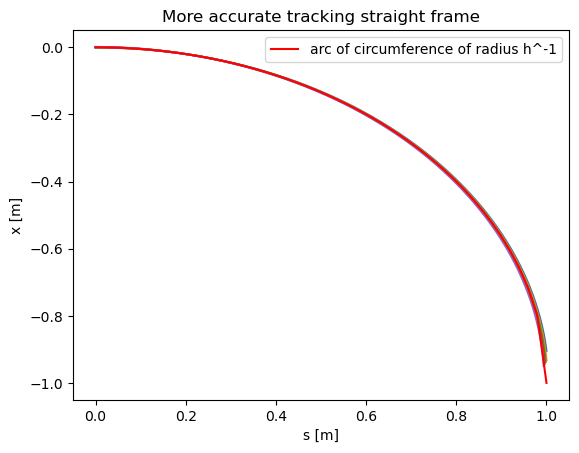

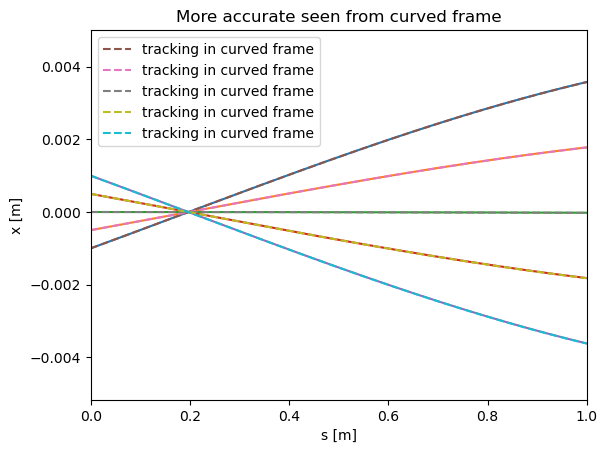

In [60]:
Astrbetter=bpmeth.GeneralVectorPotential(h=0, b=b_nfit, a=a_nfit, nphi=7)#accounts for the s dependence of the coefficients
Hstrbetter = bpmeth.Hamiltonian(length=1,h=0, vectp=Astrbetter)
p_3 = p0.copy()
sol_strbetter = Hstrbetter.track(p_3, return_sol=True, ivp_opt= {"rtol":1e-10, "atol":1e-12})
for ss in sol_strbetter:
    plt.plot(ss.t, ss.y[0])
plt.xlabel('s [m]')
plt.ylabel('x [m]')
plt.title("More accurate tracking straight frame")
x=np.linspace(0,1,50)
y= -1/h +np.sqrt(h**-2 -x**2)
plt.plot(x,y, color='red', label='arc of circumference of radius h^-1')
plt.legend()
plt.show()
#visualise from the pov of the curved frame
for ss in sol_strbetter:
    xc=np.sqrt((ss.y[0]+1/h)**2+ss.t**2)-1/h
    sc=np.arctan(ss.t/(ss.y[0]+1/h))/h
    plt.plot(sc,xc)
plt.xlabel('s [m]')
plt.ylabel('x [m]')
plt.title("More accurate seen from curved frame")
# x=np.linspace(0,1,50)
# y= np.zeros(50)
# plt.plot(x,y, color='red', label='arc of circumference of radius h^-1')
for ss in sol_curved:
    plt.plot(ss.t, ss.y[0],'--',label='tracking in curved frame')
plt.legend()
plt.xlim((0., 1.))#because H curved has length 1
plt.show()

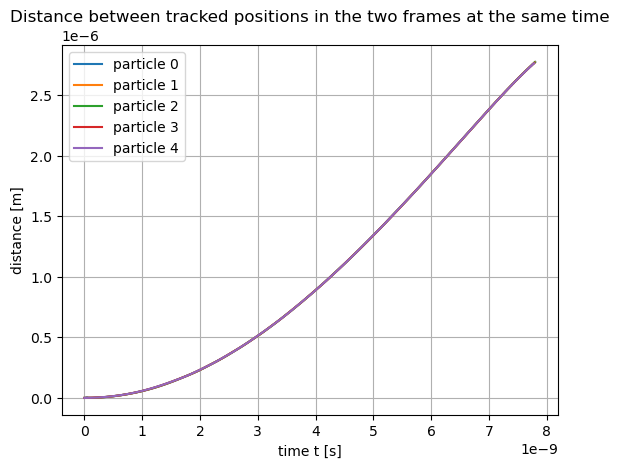

In [61]:
#project the coordinates tracked in the two frames onto a global frame (corresponding to the straight frame in practice)
from scipy.interpolate import PchipInterpolator
import numpy as np
import matplotlib.pyplot as plt

rho = 1.0 / h
c = 299792458.0

def global_from_straight(sb, beta0):
    s = sb.t
    x = sb.y[0]
    tau = sb.y[2]

    t = (s / beta0 - tau) / c

    X = x
    Z = s
    return t, X, Z

def global_from_curved(sa, beta0, h):
    rho = 1.0 / h
    s = sa.t
    x = sa.y[0]
    tau = sa.y[2]

    t = (s / beta0 - tau) / c

    X = -rho + (rho + x) * np.cos(h * s)
    Z = (rho + x) * np.sin(h * s)

    return t, X, Z


plt.figure()
all_dt = []

for i, (sb, sa) in enumerate(zip(sol_strbetter, sol_curved)):
    t_str, X_str, Z_str = global_from_straight(sb, beta0)
    t_cur, X_cur, Z_cur = global_from_curved(sa, beta0, h)

    # sort by time
    idx_str = np.argsort(t_str)
    idx_cur = np.argsort(t_cur)

    t_str = t_str[idx_str]
    X_str = X_str[idx_str]
    Z_str = Z_str[idx_str]

    t_cur = t_cur[idx_cur]
    X_cur = X_cur[idx_cur]
    Z_cur = Z_cur[idx_cur]

    # common time interval
    t_min = max(t_str.min(), t_cur.min())
    t_max = min(t_str.max(), t_cur.max())

    if t_max <= t_min:
        continue

    t_common = np.linspace(t_min, t_max, 500)

    # PCHIP interpolation
    X_str_t = PchipInterpolator(t_str, X_str)(t_common)
    Z_str_t = PchipInterpolator(t_str, Z_str)(t_common)

    X_cur_t = PchipInterpolator(t_cur, X_cur)(t_common)
    Z_cur_t = PchipInterpolator(t_cur, Z_cur)(t_common)

    # distance for this particle
    d_t = np.sqrt((X_str_t - X_cur_t)**2 + (Z_str_t - Z_cur_t)**2)
    all_dt.append((t_common, d_t))

    plt.plot(t_common, d_t, label=f"particle {i}")

plt.xlabel("time t [s]")
plt.ylabel("distance [m]")
plt.grid(True)
plt.legend()
plt.title("Distance between tracked positions in the two frames at the same time")
plt.show()

particle 0: RMS_x = 1.732e-06 m
particle 1: RMS_x = 1.733e-06 m
particle 2: RMS_x = 1.734e-06 m
particle 3: RMS_x = 1.734e-06 m
particle 4: RMS_x = 1.735e-06 m


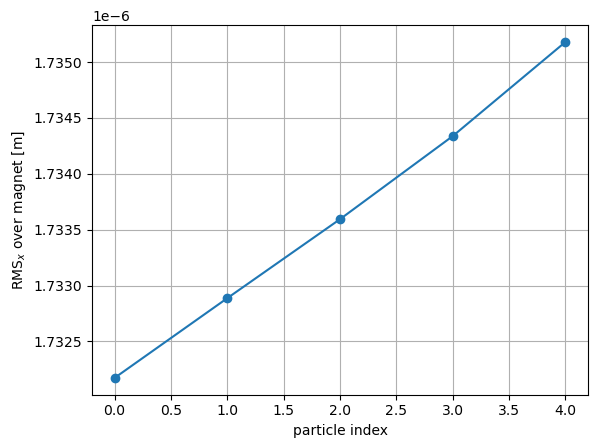

In [69]:
rms_x_list = []

for i, (sb, sa) in enumerate(zip(sol_strbetter, sol_curved)):
    # --- straight-frame tracking ---
    sbar_str = sb.t        # straight longitudinal coordinate \bar{s}
    xbar_str = sb.y[0]     # straight transverse coordinate \bar{x}

    # --- curved-frame tracking, transformed into straight frame ---
    s_curv = sa.t          # Frenet s
    x_curv = sa.y[0]       # Frenet x

    # transform (x,s) → (\bar{x}, \bar{s}) in straight frame
    sbar_from_curv = (rho + x_curv) * np.sin(s_curv / rho)
    xbar_from_curv = -rho + (rho + x_curv) * np.cos(s_curv / rho)

    # restrict to common longitudinal range in straight frame
    sbar_min = max(sbar_str.min(), sbar_from_curv.min())
    sbar_max = min(sbar_str.max(), sbar_from_curv.max())
    if sbar_max <= sbar_min:
        print(f"particle {i}: no overlap in sbar range, skipping")
        continue

    # common straight-frame grid
    sbar_common = np.linspace(sbar_min, sbar_max, 500)

    # interpolate straight tracking onto sbar_common
    xbar_str_common = PchipInterpolator(sbar_str, xbar_str)(sbar_common)

    # interpolate curved→straight tracking onto sbar_common
    # sort because sbar_from_curv may not be monotone
    idx_curv = np.argsort(sbar_from_curv)
    sbar_sorted = sbar_from_curv[idx_curv]
    xbar_sorted = xbar_from_curv[idx_curv]

    xbar_curv_common = PchipInterpolator(sbar_sorted, xbar_sorted)(sbar_common)

    # pointwise difference
    dx = xbar_str_common - xbar_curv_common

    # RMS transverse difference over the magnet
    rms_x = np.sqrt(np.mean(dx**2))
    rms_x_list.append(rms_x)

    print(f"particle {i}: RMS_x = {rms_x:.3e} m")

# summary plot over particles
plt.figure()
plt.plot(range(len(rms_x_list)), rms_x_list, "o-")
plt.xlabel("particle index")
plt.ylabel(r"RMS$_x$ over magnet [m]")
plt.grid(True)
plt.show()

particle 0: dx_exit = 3.263e-06 m, RMS_x = 1.732e-06 m
particle 1: dx_exit = 3.221e-06 m, RMS_x = 1.733e-06 m
particle 2: dx_exit = 3.098e-06 m, RMS_x = 1.734e-06 m
particle 3: dx_exit = 2.866e-06 m, RMS_x = 1.734e-06 m
particle 4: dx_exit = 2.493e-06 m, RMS_x = 1.735e-06 m


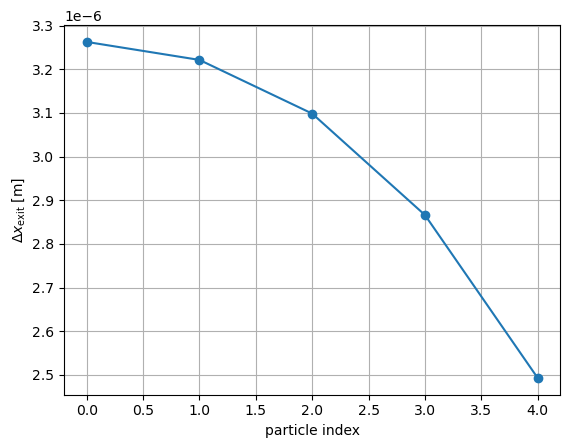

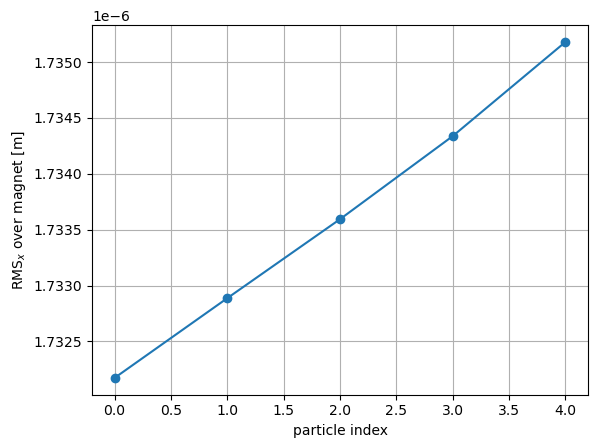

In [91]:
sbar_fin = 0.8         # chosen exit position in straight frame [m], for some reason its ok until 0.7m

dx_exit_list = []      # Δx at exit
rms_x_list = []        # RMS over magnet

for i, (sb, sa) in enumerate(zip(sol_strbetter, sol_curved)):
    # --- straight-frame tracking ---
    sbar_str = sb.t        # straight longitudinal coordinate \bar{s}
    xbar_str = sb.y[0]     # straight transverse coordinate \bar{x}

    # --- curved-frame tracking, transformed into straight frame ---
    s_curv = sa.t
    x_curv = sa.y[0]

    sbar_from_curv = (rho + x_curv) * np.sin(s_curv / rho)
    xbar_from_curv = -rho + (rho + x_curv) * np.cos(s_curv / rho)

    # --- common sbar range for RMS ---
    sbar_min = max(sbar_str.min(), sbar_from_curv.min())
    sbar_max = min(sbar_str.max(), sbar_from_curv.max())
    if sbar_max <= sbar_min:
        print(f"particle {i}: no overlap in sbar range, skipping")
        continue

    sbar_common = np.linspace(sbar_min, sbar_max, 500)

    # interpolate straight tracking onto sbar_common
    xbar_str_common = PchipInterpolator(sbar_str, xbar_str)(sbar_common)

    # interpolate curved→straight tracking onto sbar_common
    idx_curv = np.argsort(sbar_from_curv)
    sbar_sorted = sbar_from_curv[idx_curv]
    xbar_sorted = xbar_from_curv[idx_curv]

    xbar_curv_common = PchipInterpolator(sbar_sorted, xbar_sorted)(sbar_common)

    # --- RMS difference over magnet ---
    dx_all = xbar_str_common - xbar_curv_common
    rms_x = np.sqrt(np.mean(dx_all**2))
    rms_x_list.append(rms_x)

    # --- difference at exit sbar_fin (local diagnostic) ---
    # straight x at exit
    xbar_exit_straight = np.interp(sbar_fin, sbar_str, xbar_str)

    # curved→straight x at the same exit
    # reuse sorted arrays; interpolate in sbar
    xbar_exit_from_curv = np.interp(sbar_fin, sbar_sorted, xbar_sorted)

    dx_exit = xbar_exit_straight - xbar_exit_from_curv
    dx_exit_list.append(dx_exit)

    print(
        f"particle {i}: "
        f"dx_exit = {dx_exit:.3e} m, "
        f"RMS_x = {rms_x:.3e} m"
    )

# optional: summary plots
plt.figure()
plt.plot(range(len(dx_exit_list)), dx_exit_list, "o-")
plt.xlabel("particle index")
plt.ylabel(r"$\Delta x_{\text{exit}}$ [m]")
plt.grid(True)

plt.figure()
plt.plot(range(len(rms_x_list)), rms_x_list, "o-")
plt.xlabel("particle index")
plt.ylabel(r"RMS$_x$ over magnet [m]")
plt.grid(True)
plt.show()

Let's do the same for the coefficients from the transformation of $\phi$ instead than from HA.

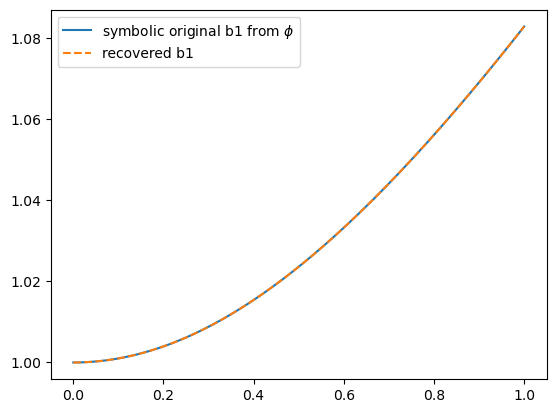

In [85]:
b_fromphifit = []
a_fromphifit = []
s = sp.symbols('s')

for arr, dst in [(b_vals.T, b_fromphifit), (a_vals.T, a_fromphifit)]:
    for j in range(arr.shape[1]):
        cheb = np.polynomial.Chebyshev.fit(sstraightarray, arr[:, j], deg=degree, domain=[0, 1])
        poly = cheb.convert(kind=np.polynomial.Polynomial)
        coeffs = poly.coef
        poly_expr = sum(sp.Float(coeffs[i]) * s**i for i in range(len(coeffs)))
        dst.append(sp.expand(poly_expr))   # store SymPy expr, not str


plt.plot(sstraightarray, b_vals.T[:, 0], label=r"symbolic original b1 from $\phi$")
# use b_fromphifit (not b_nfit), index 0 = b_1(s)
b1ofsfromphilambdified = sp.lambdify(s, b_fromphifit[0], modules='numpy')
plt.plot(sstraightarray, b1ofsfromphilambdified(sstraightarray), '--', label='recovered b1')
plt.legend()
plt.show()

do the tracking with the coefficients from phi

<lambdifygenerated-391>:3: RuntimeWarning: invalid value encountered in sqrt
  return [-(-px - y**4*(-0.00710981098570839*s**9 + 0.0684812202740868*s**8 - 0.202316991365186*s**7 + 0.291783565472859*s**6 - 0.244397334128966*s**5 + 0.135922835132237*s**4 - 0.0544236242206683*s**3 + 0.00731375185820072*s**2 + 0.00769059344750774*s - 1/17280*x**6*(717641.05099313*s**7 - 2590936.33915375*s**6 + 3642662.28209843*s**5 - 2437824.47930688*s**4 + 723366.233600453*s**3 - 43156.2282350976*s**2 - 11497.2447584098*s + 63.2050991547189) - 1/2880*x**5*(-63211.6388709252*s**7 + 242183.402485816*s**6 - 366171.559380029*s**5 + 269415.503666324*s**4 - 92681.1771595094*s**3 + 9543.91829959594*s**2 + 887.814739401883*s + 14.3728065652044) - 1/576*x**4*(5048.69765286483*s**7 - 20855.254786843*s**6 + 34280.3661883525*s**5 - 27707.0900506122*s**4 + 10628.2245381933*s**3 - 1271.4397782838*s**2 - 117.545016831795*s - 2.80387119582597) - 1/576*x**4*(9967.23681934903*s**9 - 46266.7203420313*s**8 + 86730.0543356768

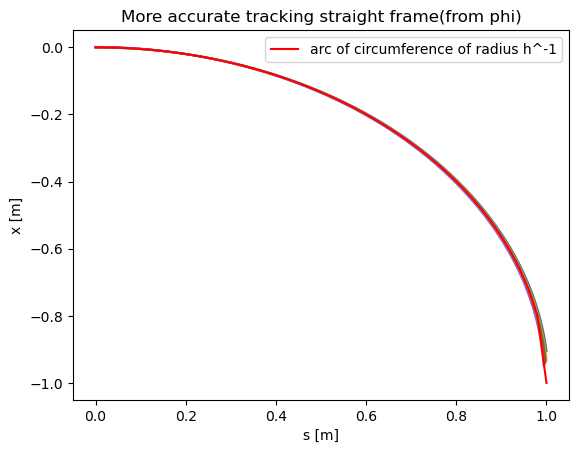

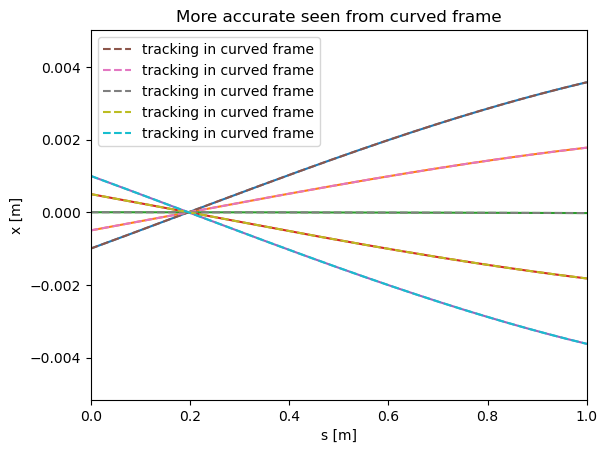

In [87]:
Astrfromphi=bpmeth.GeneralVectorPotential(h=0, b=b_fromphifit, a=a_fromphifit)#accounts for the s dependence of the coefficients
Hstrfromphi = bpmeth.Hamiltonian(length=1,h=0, vectp=Astrfromphi)
p_4 = p0.copy()
sol_strfromphi = Hstrfromphi.track(p_4, return_sol=True, ivp_opt= {"rtol":1e-10, "atol":1e-12})
for ss in sol_strfromphi:
    plt.plot(ss.t, ss.y[0])
plt.xlabel('s [m]')
plt.ylabel('x [m]')
plt.title("More accurate tracking straight frame(from phi)")
x=np.linspace(0,1,50)
y= -1/h +np.sqrt(h**-2 -x**2)
plt.plot(x,y, color='red', label='arc of circumference of radius h^-1')
plt.legend()
plt.show()
#visualise from the pov of the curved frame
for ss in sol_strfromphi:
    xc=np.sqrt((ss.y[0]+1/h)**2+ss.t**2)-1/h
    sc=np.arctan(ss.t/(ss.y[0]+1/h))/h
    plt.plot(sc,xc)
plt.xlabel('s [m]')
plt.ylabel('x [m]')
plt.title("More accurate seen from curved frame")
# x=np.linspace(0,1,50)
# y= np.zeros(50)
# plt.plot(x,y, color='red', label='arc of circumference of radius h^-1')
for ss in sol_curved:
    plt.plot(ss.t, ss.y[0],'--',label='tracking in curved frame')
plt.legend()
plt.xlim((0., 1.))#because H curved has length 1
plt.show()

particle 0: dx_exit = -6.224e-07 m, RMS_x = 5.414e-09 m
particle 1: dx_exit = -6.934e-07 m, RMS_x = 5.466e-09 m
particle 2: dx_exit = -8.469e-07 m, RMS_x = 5.574e-09 m
particle 3: dx_exit = -1.110e-06 m, RMS_x = 5.675e-09 m
particle 4: dx_exit = -1.515e-06 m, RMS_x = 5.701e-09 m


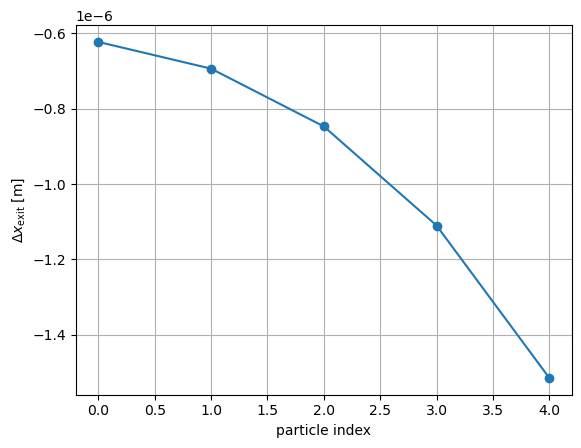

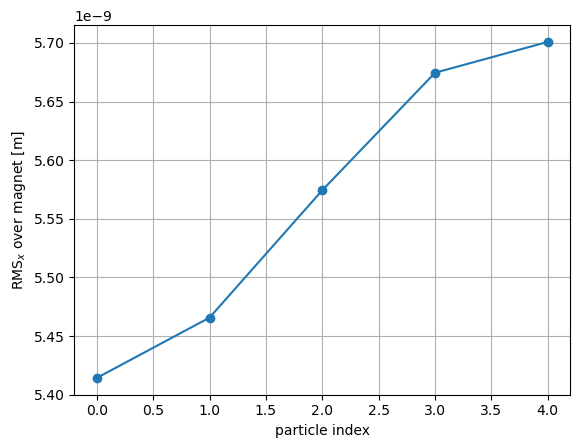

In [95]:
sbar_fin = 0.8         # chosen exit position in straight frame [m], for some reason its ok until 0.7m

dx_exit_list = []      # Δx at exit
rms_x_list = []        # RMS over magnet

for i, (sb, sa) in enumerate(zip(sol_strfromphi, sol_curved)):
    # --- straight-frame tracking ---
    sbar_str = sb.t        # straight longitudinal coordinate \bar{s}
    xbar_str = sb.y[0]     # straight transverse coordinate \bar{x}

    # --- curved-frame tracking, transformed into straight frame ---
    s_curv = sa.t
    x_curv = sa.y[0]

    sbar_from_curv = (rho + x_curv) * np.sin(s_curv / rho)
    xbar_from_curv = -rho + (rho + x_curv) * np.cos(s_curv / rho)

    # --- common sbar range for RMS ---
    sbar_min = max(sbar_str.min(), sbar_from_curv.min())
    sbar_max = min(sbar_str.max(), sbar_from_curv.max())
    if sbar_max <= sbar_min:
        print(f"particle {i}: no overlap in sbar range, skipping")
        continue

    sbar_common = np.linspace(sbar_min, sbar_max, 500)

    # interpolate straight tracking onto sbar_common
    xbar_str_common = PchipInterpolator(sbar_str, xbar_str)(sbar_common)

    # interpolate curved→straight tracking onto sbar_common
    idx_curv = np.argsort(sbar_from_curv)
    sbar_sorted = sbar_from_curv[idx_curv]
    xbar_sorted = xbar_from_curv[idx_curv]

    xbar_curv_common = PchipInterpolator(sbar_sorted, xbar_sorted)(sbar_common)

    # --- RMS difference over magnet ---
    dx_all = xbar_str_common - xbar_curv_common
    rms_x = np.sqrt(np.mean(dx_all**2))
    rms_x_list.append(rms_x)

    # --- difference at exit sbar_fin (local diagnostic) ---
    # straight x at exit
    xbar_exit_straight = np.interp(sbar_fin, sbar_str, xbar_str)

    # curved→straight x at the same exit
    # reuse sorted arrays; interpolate in sbar
    xbar_exit_from_curv = np.interp(sbar_fin, sbar_sorted, xbar_sorted)

    dx_exit = xbar_exit_straight - xbar_exit_from_curv
    dx_exit_list.append(dx_exit)

    print(
        f"particle {i}: "
        f"dx_exit = {dx_exit:.3e} m, "
        f"RMS_x = {rms_x:.3e} m"
    )

# optional: summary plots
plt.figure()
plt.plot(range(len(dx_exit_list)), dx_exit_list, "o-")
plt.xlabel("particle index")
plt.ylabel(r"$\Delta x_{\text{exit}}$ [m]")
plt.grid(True)

plt.figure()
plt.plot(range(len(rms_x_list)), rms_x_list, "o-")
plt.xlabel("particle index")
plt.ylabel(r"RMS$_x$ over magnet [m]")
plt.grid(True)
plt.show()

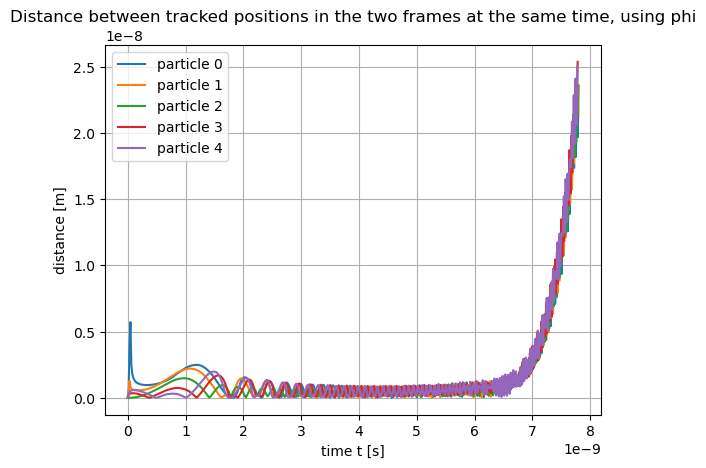

In [96]:
#project the coordinates tracked in the two frames onto a global frame (corresponding to the straight frame in practice)

plt.figure()
all_dt = []

for i, (sb, sa) in enumerate(zip(sol_strfromphi, sol_curved)):
    t_str, X_str, Z_str = global_from_straight(sb, beta0)
    t_cur, X_cur, Z_cur = global_from_curved(sa, beta0, h)

    # sort by time
    idx_str = np.argsort(t_str)
    idx_cur = np.argsort(t_cur)

    t_str = t_str[idx_str]
    X_str = X_str[idx_str]
    Z_str = Z_str[idx_str]

    t_cur = t_cur[idx_cur]
    X_cur = X_cur[idx_cur]
    Z_cur = Z_cur[idx_cur]

    # common time interval
    t_min = max(t_str.min(), t_cur.min())
    t_max = min(t_str.max(), t_cur.max())

    if t_max <= t_min:
        continue

    t_common = np.linspace(t_min, t_max, 500)

    # PCHIP interpolation
    X_str_t = PchipInterpolator(t_str, X_str)(t_common)
    Z_str_t = PchipInterpolator(t_str, Z_str)(t_common)

    X_cur_t = PchipInterpolator(t_cur, X_cur)(t_common)
    Z_cur_t = PchipInterpolator(t_cur, Z_cur)(t_common)

    # distance for this particle
    d_t = np.sqrt((X_str_t - X_cur_t)**2 + (Z_str_t - Z_cur_t)**2)
    all_dt.append((t_common, d_t))

    plt.plot(t_common, d_t, label=f"particle {i}")

plt.xlabel("time t [s]")
plt.ylabel("distance [m]")
plt.grid(True)
plt.legend()
plt.title("Distance between tracked positions in the two frames at the same time, using phi")
plt.show()